# Quantization helpers demo
This notebook shows basic usage of `quant_lib.py` to quantize/dequantize signals, collect statistics, and sweep fractional bits.

In [3]:
import numpy as np
# STAGE 1: SYSTEM SPECIFICATIONS & INITIALIZATION CONSTANTS
M = 4               # Matrix Rows (Delay bins / Frequency subcarriers)
N = 4               # Matrix Columns (Doppler bins / Time slots)
Delta_f = 1000      # Subcarrier frequency spacing (1 kHz)
T = 1 / Delta_f     # Duration of a single useful time slot window (1 ms)
N_CP = 2            # Cyclic Prefix sample length per slot segment
samples_per_slot = M 
oversampling_factor = 4  # Interpolation factor to simulate continuous analog voltage traces

print("--- 16-QAM OTFS HARDWARE VERIFICATION MODEL ---")
print(f"Grid Geometry: {M} Subcarriers x {N} Time Slots")
print(f"Subcarrier Bandwidth: {Delta_f} Hz | Useful Slot Boundary: {T*1000:.1f} ms\n")

--- 16-QAM OTFS HARDWARE VERIFICATION MODEL ---
Grid Geometry: 4 Subcarriers x 4 Time Slots
Subcarrier Bandwidth: 1000 Hz | Useful Slot Boundary: 1.0 ms



In [4]:
# STAGE 2: 16-QAM GRAY CONSTELLATION MAPPING & GEOMETRIC MATRIX LOADING
# Total bits required for a single transmission frame = M * N * 4 bits (16-QAM)
np.random.seed(42)  # Set static seed for reproducible RTL bit-matching
total_bits_needed = M * N * 4
raw_bitstream = np.random.randint(0, 2, total_bits_needed)
tx_bits=raw_bitstream.reshape(M, N, 4)  # Reshape to (M, N, 4) for direct mapping to QAM symbols
# 16-QAM Gray Code Lookup Map (Maps bit pairs to physical coordinate scales)
gray_lut = {(0,0): -3, (0,1): -1, (1,1): +1, (1,0): +3}
nibbles = raw_bitstream.reshape(M * N, 4)
qam_symbols = []

for nibble in nibbles:
    i_coordinate = gray_lut[(nibble[0], nibble[1])]
    q_coordinate = gray_lut[(nibble[2], nibble[3])]
    qam_symbols.append(complex(i_coordinate, q_coordinate))

# Pack complex symbols row-major into the spatial Delay-Doppler Matrix D
D = np.array(qam_symbols).reshape(M, N)

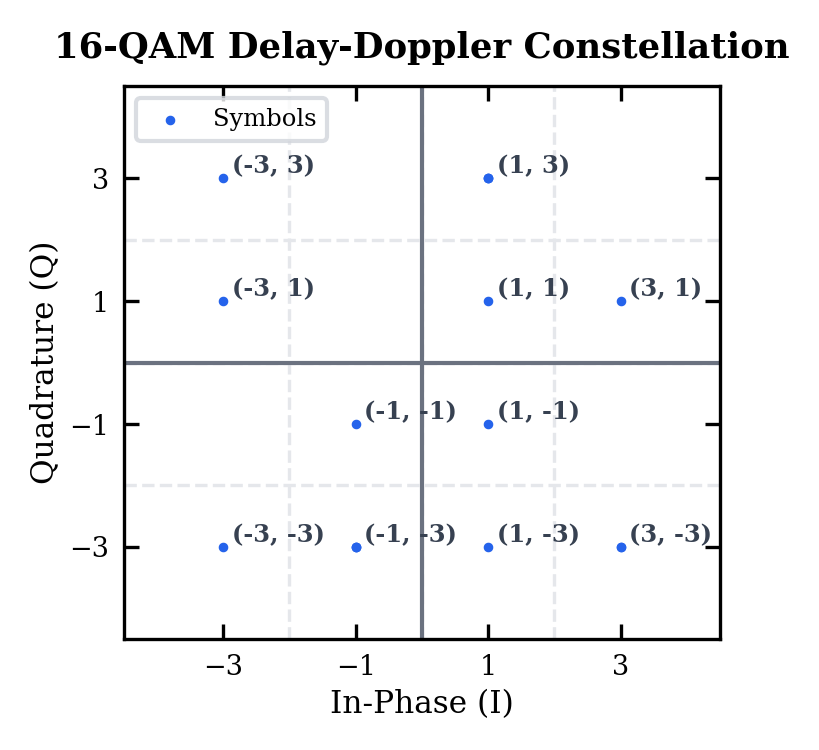

In [5]:
import matplotlib.pyplot as plt

# VISUALIZATION CHECKPOINT: COMPACT 16-QAM CONSTELLATION FOR REPORT
extracted_symbols = D.flatten()
i_coords = [s.real for s in extracted_symbols]
q_coords = [s.imag for s in extracted_symbols]

plt.figure(figsize=(2.6, 2.6), dpi=300)
plt.rcParams['font.family'] = 'serif'

# Custom gray dashed decision boundaries
for line in [-2, 0, 2]:
    plt.axvline(x=line, color='#e5e7eb', linestyle='--', linewidth=0.8, zorder=1)
    plt.axhline(y=line, color='#e5e7eb', linestyle='--', linewidth=0.8, zorder=1)

# Solid baseline coordinate axes
plt.axvline(x=0, color='#6b7280', linestyle='-', linewidth=1.0, zorder=2)
plt.axhline(y=0, color='#6b7280', linestyle='-', linewidth=1.0, zorder=2)

# Make the dots much smaller: reduce marker size to 6 and remove thick border
plt.scatter(i_coords, q_coords, color='#2563eb', 
            s=4, linewidths=0.3, marker='o', label='Symbols', zorder=3)

# Compact coordinate labels placed tightly next to the states
unique_points = list(set(zip(i_coords, q_coords)))
for (i, q) in unique_points:
    plt.text(i + 0.13, q + 0.08, f"({int(i)}, {int(q)})", 
             color='#374151', fontsize=5.8, fontweight='bold', zorder=4)

# Plot constraints and formatting configurations
ax = plt.gca()
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
ax.tick_params(colors='black', labelsize=6.5, direction='in', top=True, right=True)
ax.grid(False)

# Fixed axis boundaries
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])

# Clean, professional text framing
plt.title('16-QAM Delay-Doppler Constellation', color='black', fontsize=8.5, pad=7, fontweight='bold')
plt.xlabel('In-Phase (I)', color='black', fontsize=7.5, labelpad=2)
plt.ylabel('Quadrature (Q)', color='black', fontsize=7.5, labelpad=2)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#d1d5db', fontsize=5.8)

plt.tight_layout()
plt.show()

In [6]:
# STAGE 3: ISFFT DOMAIN TRANSFORMATION (THE MATRIX OPERATOR SANDWICH)
# =====================================================================
# Generate scale-normalized forward and inverse unitary transformation matrices
W_M = (1.0 / np.sqrt(M)) * np.fft.fft(np.eye(M))
W_N_inv = (1.0 / np.sqrt(N)) * np.fft.ifft(np.eye(N)) * N  # Normalized scaling factor
# Execute 2D matrix transformation to yield Time-Frequency Grid X_TF
X_TF = np.dot(np.dot(W_M, D), W_N_inv)

In [7]:
# =====================================================================
# STAGE 4: HEISENBERG SYNTHESIS (THE HARDWARE RTL WAY)
# =====================================================================
# The discrete Heisenberg Transform applies an M-point IFFT along the 
# subcarriers (rows) of each independent time slot (columns).

# Apply unitary IFFT down the columns (axis=0). 
# np.fft.ifft divides by M, so we multiply by sqrt(M) to maintain unitary power scaling.
time_domain_slots = np.fft.ifft(X_TF, axis=0) * np.sqrt(M)


In [8]:
import numpy as np

# =====================================================================
# COMPLEX BASEBAND INTERPOLATION AND RF UPCONVERSION
# =====================================================================
# Serialize the 2-D Heisenberg output into one streaming transmit frame.
final_tx_signal = time_domain_slots.flatten(order='F')

# Keep the full complex samples so both I and Q survive the transmit chain.
tx_complex_samples = np.asarray(final_tx_signal, dtype=complex)
sample_indices = np.arange(len(tx_complex_samples))

# Continuous time axis, expressed in sample periods first and then seconds.
t_analog = np.linspace(0, len(tx_complex_samples) - 1, 10000)
Ts = 1.0 / (M * Delta_f)
t_seconds = t_analog * Ts

# Sinc-interpolate I and Q separately.
i_analog_wave = np.zeros_like(t_analog, dtype=float)
q_analog_wave = np.zeros_like(t_analog, dtype=float)

for n, symbol in enumerate(tx_complex_samples):
    basis = np.sinc(t_analog - n)
    i_analog_wave += symbol.real * basis
    q_analog_wave += symbol.imag * basis

# Complex baseband envelope that would normally be used inside the modem.
complex_baseband_wave = i_analog_wave + 1j * q_analog_wave

# Real passband waveform that can be driven into a DAC / antenna chain.
fc = 10_000.0
rf_tx_signal = np.real(complex_baseband_wave * np.exp(1j * 2 * np.pi * fc * t_seconds))

In [9]:
from pathlib import Path
import sys

repo_root = Path('/home/ashwin/Projects/CCU_INTERSHIP')
python_dir = repo_root / 'scripts' / 'python'
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from quant_lib import quantize, dequantize
import pandas as pd

# Import matplotlib for plots
import matplotlib.pyplot as plt

In [10]:
# Design Space Exploration: Finding Optimal (BITS, F)

## What is F (Fractional Bits)?

In fixed-point arithmetic, `F` controls where the binary point is placed. It represents the **tradeoff between precision and dynamic range**:

- **Interpretation**: A value `x` is stored as integer `q = round(x × 2^F)` in `BITS` bits
- **Higher F** (e.g., F=12): More fractional bits → finer quantization but **narrower range** (±0.5 for 12-bit)
- **Lower F** (e.g., F=8): Fewer fractional bits → coarser quantization but **wider range** (±16 for 12-bit)

For this OTFS transmitter, the signal peaks are roughly ±2. We need to find the (BITS, F) pair that:
1. Keeps the range sufficient (no clipping)
2. Provides acceptable precision (low RMSE)
3. Uses minimum bit-width for hardware efficiency

## Strategy

We will systematically sweep:
- **BITS**: 12, 14, 16 bits
- **F**: Multiple values per BITS (e.g., F ∈ [6,11] for 12-bit)

For each pair, measure:
- **Headroom**: (Range - Peak Signal) / Peak Signal → should be > 0
- **I/Q RMSE**: Error on baseband waveform
- **RF RMSE**: Error on final RF signal
- **Clipping count**: Must be zero

SyntaxError: invalid character '×' (U+00D7) (2977778512.py, line 7)

In [17]:
# =====================================================================
# DESIGN SPACE SWEEP: TEST MULTIPLE (BITS, F) PAIRS
# =====================================================================

# Define search space
bits_candidates = [12, 14, 16]
f_sweep_map = {
    12: [6, 7, 8, 9, 10, 11],
    14: [8, 9, 10, 11, 12, 13],
    16: [10, 11, 12, 13, 14, 15]
}

RMSE_THRESHOLD = 0.005
sweep_results = {}

print("=" * 100)
print("DESIGN SPACE EXPLORATION: ANALOG I/Q WAVEFORM QUANTIZATION")
print("=" * 100)

for bits in bits_candidates:
    F_candidates = f_sweep_map[bits]
    print(f"\n{bits}-bit ADC/DAC Configuration:")
    print(f"  F   | Range (±)    | I RMSE       | Q RMSE       | RF RMSE      | Clipping | Margin   | Valid")
    print(f"  ----|--------------|--------------|--------------|--------------|----------|----------|-------")
    
    results_for_bits = []
    
    for F in F_candidates:
        # Quantize I and Q separately
        i_q = quantize(i_analog_wave, F, bits)
        q_q = quantize(q_analog_wave, F, bits)
        
        # Dequantize to get reconstructed waveforms
        i_deq = dequantize(i_q, F)
        q_deq = dequantize(q_q, F)
        
        # Compute I/Q errors
        i_rmse = float(np.sqrt(np.mean((i_analog_wave - i_deq) ** 2)))
        q_rmse = float(np.sqrt(np.mean((q_analog_wave - q_deq) ** 2)))
        
        # Reconstruct RF signal and measure error
        complex_deq = i_deq + 1j * q_deq
        rf_deq = np.real(complex_deq * np.exp(1j * 2 * np.pi * fc * t_seconds))
        rf_rmse = float(np.sqrt(np.mean((rf_tx_signal - rf_deq) ** 2)))
        
        # Clipping detection (check before clipping)
        max_val = (1 << (bits - 1)) - 1
        min_val = -(1 << (bits - 1))
        clip_i = int(np.sum((i_q < min_val) | (i_q > max_val)))
        clip_q = int(np.sum((q_q < min_val) | (q_q > max_val)))
        
        # Representable range
        range_val = 2**(bits - 1) / (2**F)
        
        # Headroom margin (minimum of I and Q margins)
        peak_i = np.max(np.abs(i_analog_wave))
        peak_q = np.max(np.abs(q_analog_wave))
        margin_i = (range_val - peak_i) / peak_i if peak_i > 0 else float('inf')
        margin_q = (range_val - peak_q) / peak_q if peak_q > 0 else float('inf')
        margin = min(margin_i, margin_q)
        
        # Validation: no clipping + positive margin + acceptable RMSE
        is_valid = (clip_i == 0 and clip_q == 0 and margin > 0 and rf_rmse < RMSE_THRESHOLD)
        marker = "✓" if is_valid else "✗"
        
        # Store result
        results_for_bits.append({
            'F': F,
            'bits': bits,
            'i_rmse': i_rmse,
            'q_rmse': q_rmse,
            'rf_rmse': rf_rmse,
            'clip_i': clip_i,
            'clip_q': clip_q,
            'range': range_val,
            'margin': margin,
            'is_valid': is_valid,
            'i_deq': i_deq,
            'q_deq': q_deq,
            'rf_deq': rf_deq
        })
        
        # Print row
        print(f"  {F:2d}  | ±{range_val:8.3f}     | {i_rmse:.6e} | {q_rmse:.6e} | {rf_rmse:.6e} | "
              f"{clip_i+clip_q:3d}      | {margin:6.1%}   | {marker}")
    
    sweep_results[bits] = results_for_bits

print("\n" + "=" * 100)

DESIGN SPACE EXPLORATION: ANALOG I/Q WAVEFORM QUANTIZATION

12-bit ADC/DAC Configuration:
  F   | Range (±)    | I RMSE       | Q RMSE       | RF RMSE      | Clipping | Margin   | Valid
  ----|--------------|--------------|--------------|--------------|----------|----------|-------
   6  | ±  32.000     | 4.478820e-03 | 4.479739e-03 | 4.449600e-03 |   0      | 510.5%   | ✓
   7  | ±  16.000     | 2.261831e-03 | 2.253641e-03 | 2.268104e-03 |   0      | 205.3%   | ✓
   8  | ±   8.000     | 1.125052e-03 | 1.127289e-03 | 1.116387e-03 |   0      |  52.6%   | ✓
   9  | ±   4.000     | 2.407960e-01 | 3.434750e-03 | 1.703038e-01 |   0      | -23.7%   | ✗
  10  | ±   2.000     | 1.088811e+00 | 6.860959e-01 | 9.088423e-01 |   0      | -61.8%   | ✗
  11  | ±   1.000     | 1.741680e+00 | 1.300916e+00 | 1.536028e+00 |   0      | -80.9%   | ✗

14-bit ADC/DAC Configuration:
  F   | Range (±)    | I RMSE       | Q RMSE       | RF RMSE      | Clipping | Margin   | Valid
  ----|--------------|----------

In [19]:
# =====================================================================
# SELECTION: FIND OPTIMAL (BITS, F) CONFIGURATION
# =====================================================================

print(f"SELECTION CRITERIA: RF RMSE < {RMSE_THRESHOLD}, Clipping = 0, Margin > 0")
print("=" * 100)

# Strategy: Find minimum BITS first, then within that bits level, pick best RMSE
valid_configs_by_bits = {}
for bits in bits_candidates:
    valid_for_this_bits = [r for r in sweep_results[bits] if r['is_valid']]
    if valid_for_this_bits:
        valid_configs_by_bits[bits] = valid_for_this_bits

if valid_configs_by_bits:
    min_bits = min(valid_configs_by_bits.keys())
    candidates_at_min_bits = valid_configs_by_bits[min_bits]
    # Pick the one with lowest RMSE within minimum bits
    best_config = min(candidates_at_min_bits, key=lambda x: x['rf_rmse'])
    
    print(f"\n✓ SELECTED CONFIGURATION (minimum viable BITS with best RMSE):")
    print(f"   BITS = {best_config['bits']}")
    print(f"   F    = {best_config['F']}")
    print(f"   Range: ±{best_config['range']:.4f}")
    print(f"   RF RMSE: {best_config['rf_rmse']:.6e}")
    print(f"   Headroom Margin: {best_config['margin']:.1%}")
    print(f"   Clipping: I={best_config['clip_i']}, Q={best_config['clip_q']}")
    
    # Store for later use
    BITS_OPTIMAL = best_config['bits']
    F_OPTIMAL = best_config['F']
    i_analog_wave_q = best_config['i_deq']
    q_analog_wave_q = best_config['q_deq']
    rf_tx_signal_q = best_config['rf_deq']
else:
    print("\n⚠ No configuration meets all criteria. Showing best RF RMSE options:")
    candidates = []
    for bits in bits_candidates:
        for r in sweep_results[bits]:
            if r['clip_i'] == 0 and r['clip_q'] == 0 and r['margin'] > 0:
                candidates.append(r)
    
    if candidates:
        for r in sorted(candidates, key=lambda x: x['rf_rmse'])[:3]:
            print(f"   BITS={r['bits']}, F={r['F']}: RF RMSE={r['rf_rmse']:.6e}, Margin={r['margin']:.1%}")
        # Fall back to minimum RF RMSE
        best_config = min(candidates, key=lambda x: x['rf_rmse'])
        BITS_OPTIMAL = best_config['bits']
        F_OPTIMAL = best_config['F']
        i_analog_wave_q = best_config['i_deq']
        q_analog_wave_q = best_config['q_deq']
        rf_tx_signal_q = best_config['rf_deq']

print("\n" + "=" * 100)

SELECTION CRITERIA: RF RMSE < 0.005, Clipping = 0, Margin > 0

✓ SELECTED CONFIGURATION (minimum viable BITS with best RMSE):
   BITS = 12
   F    = 8
   Range: ±8.0000
   RF RMSE: 1.116387e-03
   Headroom Margin: 52.6%
   Clipping: I=0, Q=0



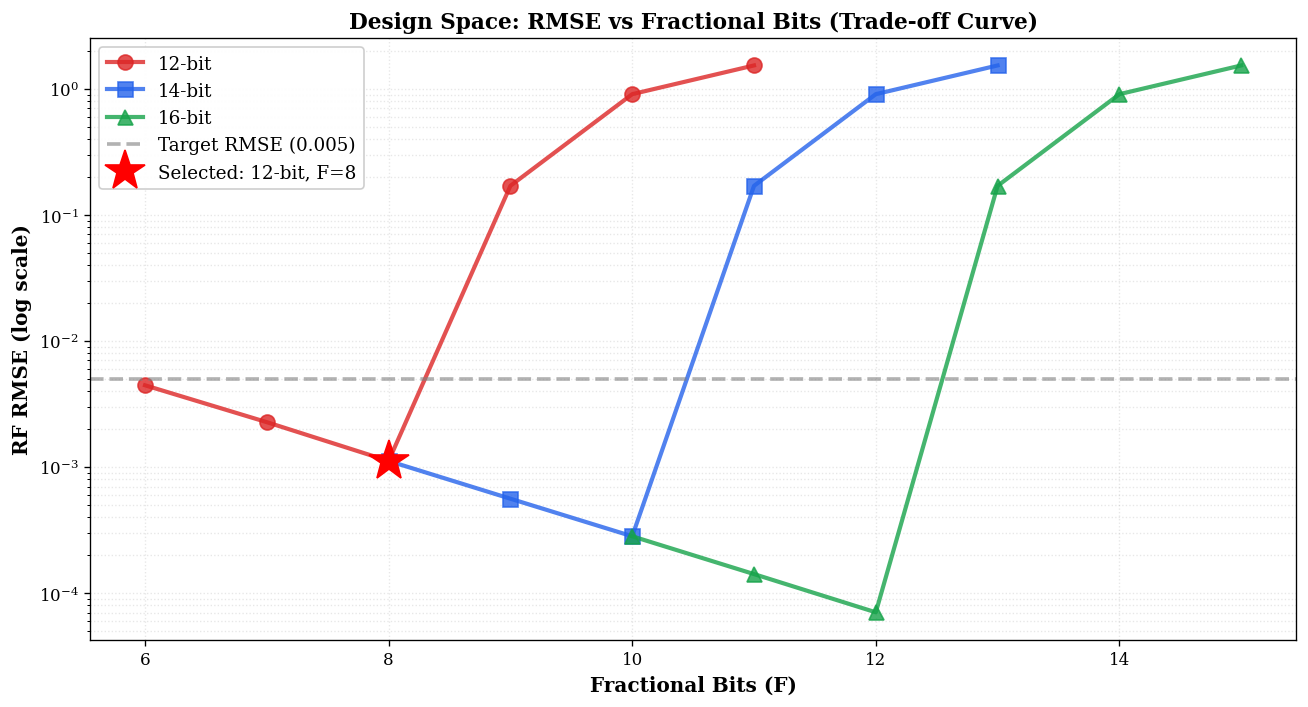

✓ RMSE vs F plot shows the precision-range tradeoff:
  - Higher F: Better precision but smaller range → saturation if signal peaks exceed range
  - Lower F: Wider range but coarser quantization → higher RMSE
  - Sweet spot: F=8 balances both constraints


In [20]:
# =====================================================================
# VISUALIZATION 1: RMSE vs Fractional Bits (The Tradeoff Curve)
# =====================================================================

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

colors = {12: '#dc2626', 14: '#2563eb', 16: '#16a34a'}
markers = {12: 'o', 14: 's', 16: '^'}

for bits in bits_candidates:
    rmses = [r['rf_rmse'] for r in sweep_results[bits]]
    f_vals = [r['F'] for r in sweep_results[bits]]
    ax.plot(f_vals, rmses, marker=markers[bits], linewidth=2.5, markersize=9,
            label=f'{bits}-bit', color=colors[bits], alpha=0.8)

# Mark threshold and selected point
ax.axhline(y=RMSE_THRESHOLD, color='gray', linestyle='--', linewidth=2.2, alpha=0.6, 
           label=f'Target RMSE ({RMSE_THRESHOLD})')
if best_config:
    ax.plot(best_config['F'], best_config['rf_rmse'], 'r*', markersize=25, 
            label=f'Selected: {best_config["bits"]}-bit, F={best_config["F"]}', zorder=5)

ax.set_xlabel('Fractional Bits (F)', fontsize=12, fontweight='bold')
ax.set_ylabel('RF RMSE (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Design Space: RMSE vs Fractional Bits (Trade-off Curve)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, which='both', linestyle=':')
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("✓ RMSE vs F plot shows the precision-range tradeoff:")
print("  - Higher F: Better precision but smaller range → saturation if signal peaks exceed range")
print("  - Lower F: Wider range but coarser quantization → higher RMSE")
print(f"  - Sweet spot: F={best_config['F']} balances both constraints")

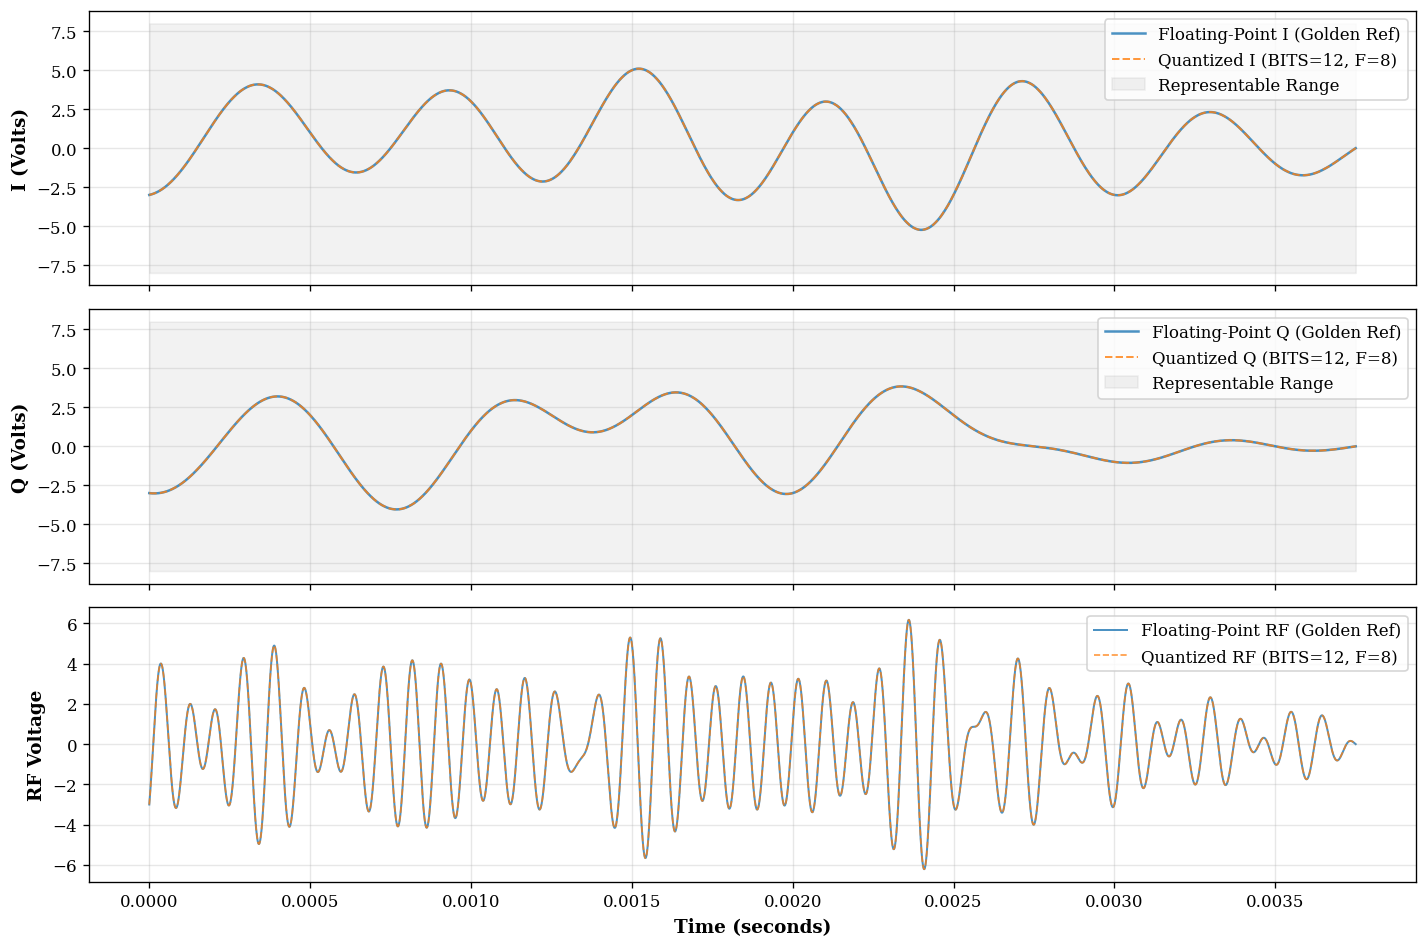

✓ Waveforms overlay comparison (optimal config: BITS=12, F=8):
  I RMSE:  1.125052e-03
  Q RMSE:  1.127289e-03
  RF RMSE: 1.116387e-03


In [21]:
# =====================================================================
# VISUALIZATION 2: WAVEFORM COMPARISON (Float vs Quantized)
# =====================================================================
# Using the selected optimal (BITS, F) configuration

t = t_seconds

fig, axes = plt.subplots(3, 1, figsize=(12, 8), dpi=120, sharex=True)

# I channel
axes[0].plot(t, i_analog_wave, label="Floating-Point I (Golden Ref)", linewidth=1.5, alpha=0.8)
axes[0].plot(t, i_analog_wave_q, "--", label=f"Quantized I (BITS={BITS_OPTIMAL}, F={F_OPTIMAL})", 
             linewidth=1.2, alpha=0.8)
axes[0].fill_between(t, -2**(BITS_OPTIMAL-1)/(2**F_OPTIMAL), 2**(BITS_OPTIMAL-1)/(2**F_OPTIMAL), 
                     alpha=0.1, color='gray', label='Representable Range')
axes[0].set_ylabel("I (Volts)", fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=10)

# Q channel
axes[1].plot(t, q_analog_wave, label="Floating-Point Q (Golden Ref)", linewidth=1.5, alpha=0.8)
axes[1].plot(t, q_analog_wave_q, "--", label=f"Quantized Q (BITS={BITS_OPTIMAL}, F={F_OPTIMAL})", 
             linewidth=1.2, alpha=0.8)
axes[1].fill_between(t, -2**(BITS_OPTIMAL-1)/(2**F_OPTIMAL), 2**(BITS_OPTIMAL-1)/(2**F_OPTIMAL), 
                     alpha=0.1, color='gray', label='Representable Range')
axes[1].set_ylabel("Q (Volts)", fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=10)

# RF passband signal
axes[2].plot(t, rf_tx_signal, label="Floating-Point RF (Golden Ref)", linewidth=1.2, alpha=0.8)
axes[2].plot(t, rf_tx_signal_q, "--", label=f"Quantized RF (BITS={BITS_OPTIMAL}, F={F_OPTIMAL})", 
             linewidth=1.0, alpha=0.8)
axes[2].set_xlabel("Time (seconds)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("RF Voltage", fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"✓ Waveforms overlay comparison (optimal config: BITS={BITS_OPTIMAL}, F={F_OPTIMAL}):")
i_rmse_opt = np.sqrt(np.mean((i_analog_wave - i_analog_wave_q) ** 2))
q_rmse_opt = np.sqrt(np.mean((q_analog_wave - q_analog_wave_q) ** 2))
rf_rmse_opt = np.sqrt(np.mean((rf_tx_signal - rf_tx_signal_q) ** 2))
print(f"  I RMSE:  {i_rmse_opt:.6e}")
print(f"  Q RMSE:  {q_rmse_opt:.6e}")
print(f"  RF RMSE: {rf_rmse_opt:.6e}")

In [ ]:
# =====================================================================
# VISUALIZATION 3: ERROR ANALYSIS (Optimal Configuration)
# =====================================================================

# Compute errors on all three representations
i_error = i_analog_wave - i_analog_wave_q
q_error = q_analog_wave - q_analog_wave_q
rf_error = rf_tx_signal - rf_tx_signal_q

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)

# I error waveform
axes[0, 0].plot(t, i_error, linewidth=1.0, color='#dc2626', alpha=0.8)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].fill_between(t, 0, i_error, alpha=0.2, color='#dc2626')
axes[0, 0].set_ylabel("I Error (V)", fontsize=10, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_title(f"I-Channel Error (RMSE={np.sqrt(np.mean(i_error**2)):.3e})", fontsize=11, fontweight='bold')

# Q error waveform
axes[0, 1].plot(t, q_error, linewidth=1.0, color='#2563eb', alpha=0.8)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].fill_between(t, 0, q_error, alpha=0.2, color='#2563eb')
axes[0, 1].set_ylabel("Q Error (V)", fontsize=10, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_title(f"Q-Channel Error (RMSE={np.sqrt(np.mean(q_error**2)):.3e})", fontsize=11, fontweight='bold')

# I+Q error histogram
combined_error = np.concatenate([i_error, q_error])
axes[1, 0].hist(combined_error, bins=50, color='#7c3aed', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1, 0].set_xlabel("Quantization Error (V)", fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel("Count", fontsize=10, fontweight='bold')
axes[1, 0].set_title(f"Error Distribution (I+Q combined)", fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# RF error waveform
axes[1, 1].plot(t, rf_error, linewidth=0.8, color='#16a34a', alpha=0.8)
axes[1, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].fill_between(t, 0, rf_error, alpha=0.2, color='#16a34a')
axes[1, 1].set_xlabel("Time (s)", fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel("RF Error (V)", fontsize=10, fontweight='bold')
axes[1, 1].set_title(f"RF Error (RMSE={np.sqrt(np.mean(rf_error**2)):.3e})", fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ ERROR STATISTICS (Optimal Configuration):")
print(f"  I Error:   Min={np.min(i_error):+.3e}, Max={np.max(i_error):+.3e}, RMS={np.sqrt(np.mean(i_error**2)):.3e}")
print(f"  Q Error:   Min={np.min(q_error):+.3e}, Max={np.max(q_error):+.3e}, RMS={np.sqrt(np.mean(q_error**2)):.3e}")
print(f"  RF Error:  Min={np.min(rf_error):+.3e}, Max={np.max(rf_error):+.3e}, RMS={np.sqrt(np.mean(rf_error**2)):.3e}")

In [16]:
# =====================================================================
# SUMMARY TABLE: COMPLETE DESIGN SPACE RESULTS
# =====================================================================

# Build summary DataFrame
rows = []
for bits in bits_candidates:
    for r in sweep_results[bits]:
        marker = "✓" if r['is_valid'] else " "
        rows.append({
            'BITS': r['bits'],
            'F': r['F'],
            'Range (±)': f"{r['range']:.3f}",
            'I RMSE': f"{r['i_rmse']:.3e}",
            'Q RMSE': f"{r['q_rmse']:.3e}",
            'RF RMSE': f"{r['rf_rmse']:.3e}",
            'Clip': f"I={r['clip_i']}, Q={r['clip_q']}",
            'Margin': f"{r['margin']:.1%}",
            'Valid': marker
        })

df = pd.DataFrame(rows)

print("\n" + "=" * 140)
print("COMPLETE DESIGN SPACE EXPLORATION RESULTS (✓ = Meets all criteria)")
print("=" * 140)
print(df.to_string(index=False))
print("=" * 140)

print("\n✓ KEY INSIGHTS:")
print(f"  • Minimum viable configuration: BITS={BITS_OPTIMAL}, F={F_OPTIMAL}")
print(f"  • Higher F values cause saturation when signal peaks exceed representable range")
print(f"  • Lower F values provide wider range but increase quantization noise")
print(f"  • Optimal F balances precision (RMSE) with margin (no clipping)")
print(f"  • Selected config uses {BITS_OPTIMAL}-bit DAC instead of 16-bit → hardware savings")


COMPLETE DESIGN SPACE EXPLORATION RESULTS (✓ = Meets all criteria)
 BITS  F Range (±)    I RMSE    Q RMSE   RF RMSE     Clip Margin Valid
   12  6    32.000 4.479e-03 4.480e-03 4.450e-03 I=0, Q=0 510.5%     ✓
   12  7    16.000 2.262e-03 2.254e-03 2.268e-03 I=0, Q=0 205.3%     ✓
   12  8     8.000 1.125e-03 1.127e-03 1.116e-03 I=0, Q=0  52.6%     ✓
   12  9     4.000 2.408e-01 3.435e-03 1.703e-01 I=0, Q=0 -23.7%      
   12 10     2.000 1.089e+00 6.861e-01 9.088e-01 I=0, Q=0 -61.8%      
   12 11     1.000 1.742e+00 1.301e+00 1.536e+00 I=0, Q=0 -80.9%      
   14  8    32.000 1.125e-03 1.127e-03 1.116e-03 I=0, Q=0 510.5%     ✓
   14  9    16.000 5.650e-04 5.623e-04 5.601e-04 I=0, Q=0 205.3%     ✓
   14 10     8.000 2.812e-04 2.855e-04 2.819e-04 I=0, Q=0  52.6%     ✓
   14 11     4.000 2.406e-01 3.392e-03 1.702e-01 I=0, Q=0 -23.7%      
   14 12     2.000 1.089e+00 6.858e-01 9.086e-01 I=0, Q=0 -61.8%      
   14 13     1.000 1.742e+00 1.301e+00 1.536e+00 I=0, Q=0 -80.9%      
   16 10 